In [29]:
# ==========================================
# ML Foundations Capstone Project
# Notebook 2: Feature Engineering
# ==========================================

# In this notebook all features will be engineered and transformed.
# Goal: Create new meaningful features, encode categorical variables,
# scale numerical data, and improve the dataset for modeling.

In [30]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [31]:
# Load the Data
df= pd.read_csv("C:\\Users\\MOJ\\Desktop\\semester 2\\Capstone project\\data\\clean_data.csv")

In [32]:
#copying the data 
df_copy = df.copy()

In [33]:
# One-hot encode categorical columns

df_copy = pd.get_dummies(df_copy, columns=['MS Zoning', 'House Style'], drop_first=True)


In [34]:
# Define ordered categories (example: quality levels in Ames Housing)
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

# Apply ordinal encoding
encoder = OrdinalEncoder(categories=[quality_order])
df_copy['Exter Qual'] = encoder.fit_transform(df_copy[['Exter Qual']])


In [ ]:
# Choose numerical columns to scale

num_cols = ['Lot Area', 'Gr Liv Area']
scaler = StandardScaler()
df_copy[num_cols] = scaler.fit_transform(df_copy[num_cols])


In [36]:
# Feature 1: price per square foot (safe division)
df_copy['price_per_sqft'] = df_copy['SalePrice'] / df_copy['Gr Liv Area'].replace(0, 1)

# Feature 2: house age at sale
df_copy['house_age'] = df_copy['Yr Sold'] - df_copy['Year Built']


In [37]:
# Interaction feature: quality × area

df_copy['quality_area'] = df_copy['Overall Qual'] * df_copy['Gr Liv Area']


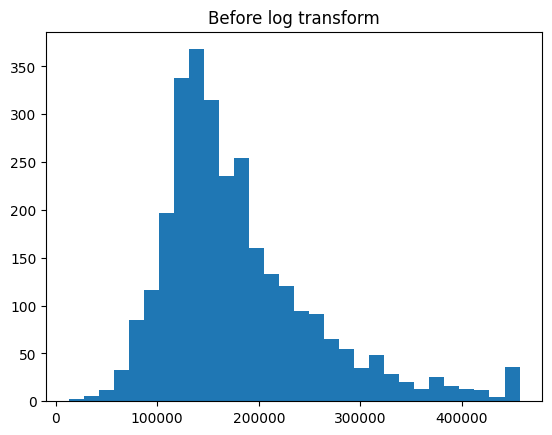

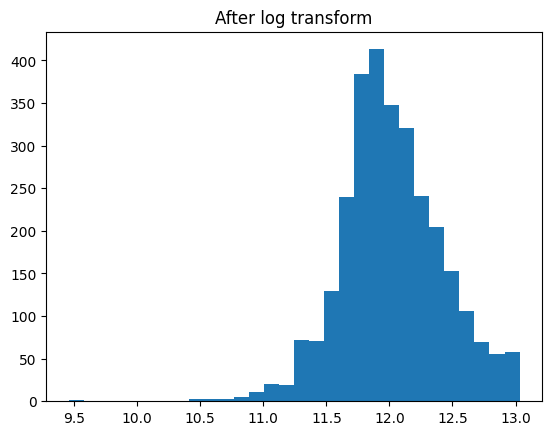

In [38]:
# Log-transform 1 skewed column + show histogram before and after

plt.figure()
plt.hist(df_copy['SalePrice'], bins=30)
plt.title("Before log transform")
plt.show()

df_copy['SalePrice_log'] = np.log1p(df_copy['SalePrice'])

plt.figure()
plt.hist(df_copy['SalePrice_log'], bins=30)
plt.title("After log transform")
plt.show()


In [39]:
# Bin 1 column into meaningful groups (age groups)

df_copy['house_age'] = df_copy['Yr Sold'] - df_copy['Year Built']
df_copy['age_group'] = pd.cut(
    df_copy['house_age'],
    bins=[-1, 10, 30, 100],
    labels=['New', 'Recent', 'Old']
)

In [40]:
# Remove redundant features with high correlation (r > 0.95)

corr_matrix = df_copy.corr(numeric_only=True)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df_copy = df_copy.drop(columns=to_drop)